In [1]:
import numpy as np
from scipy.linalg import inv
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def generate_S(p, n, sigma=1.0):
    """
    Генерирует симметризованную выборочную ковариационную матрицу размера (p+n)x(p+n).
    X - матрица данных размера p x n, элементы ~ N(0, sigma^2).
    """
    X = np.random.randn(p, n) * sigma
    S = np.zeros((p + n, p + n))
    S[:p, p:] = X
    S[p:, :p] = X.T
    return S / np.sqrt(n)

In [3]:
def plot_eigenvalues_histogram(p, n, sigma=1.0):
    S = generate_S(p, n, sigma)
    eigvals = np.linalg.eigvalsh(S)
    plt.hist(eigvals, bins=51, density=True, alpha=0.7, color='lightgreen', edgecolor='green')
    plt.xlabel("Собственные числа")
    plt.ylabel("Плотность")
    plt.title(f"Гистограмма собственных чисел S (p={p}, n={n})")
    plt.ylim(0, 1)
    plt.show()
    print(1-np.sqrt(p/n), 1+np.sqrt(p/n))
    return eigvals

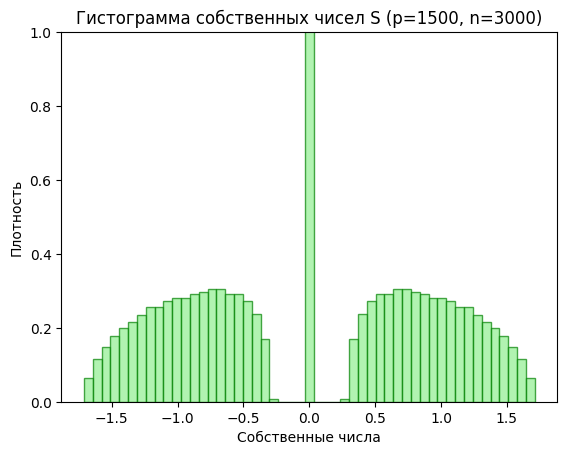

0.2928932188134524 1.7071067811865475


In [4]:
eigvals = plot_eigenvalues_histogram(1500, 3000)

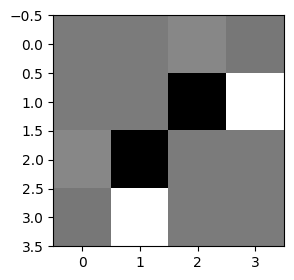

In [5]:
plt.figure(figsize=(3, 3))
plt.imshow(generate_S(2, 2), cmap='gray')

In [6]:
def resolvent(S, z):
    """R(z) = (S - z * I)^(-1)"""
    N = S.shape[0]
    return inv(S - z * np.eye(N))

In [7]:
def trace_product(S, z, A_list):
    """
    Возвращает Tr(R A1 R A2 ... R Ak)
    A_list - список [A1, A2, ..., Ak] матриц
    """
    R = resolvent(S, z)
    prod = R @ A_list[0]
    for A in A_list[1:]:
        prod = prod @ R @ A
    return np.trace(prod)

In [8]:
def empirical_cdf(data, x_values):
    """Возвращает массив F(x) = (# элементов data <= x) / len(data)"""
    n = len(data)
    cdf = np.array([np.sum(data <= x) / n for x in x_values])
    return cdf

In [9]:
def compare_cdf_with_normal(samples, title="Сравнение CDF"):
    mu = np.mean(samples)
    sigma = np.std(samples)
    
    # Точки для построения
    x_vals = np.linspace(min(samples), max(samples), 200)
    
    # Эмпирическая функция распределения
    y_emp = empirical_cdf(samples, x_vals)
    
    # Функция распределения нормального закона
    y_theor = norm.cdf(x_vals, loc=mu, scale=sigma)
    
    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_emp, color='lime', label='Эмпирическая CDF', linewidth=2)
    plt.plot(x_vals, y_theor, linestyle='--', color='maroon', label='Нормальная CDF', linewidth=5, zorder=1)

    text = f'mean = {mu:.4f}\nvar = {sigma**2:.4f}'
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel('x')
    plt.ylabel('CDF')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"Среднее = {mu:.5f}, Ст. откл. = {sigma:.5f}")

In [10]:
# Параметры
p = 200  # количество признаков
n = 300  # количество наблюдений
N = p + n  # полный размер матрицы S
y = p / n

print('интервал рассмотрения:', 1 - np.sqrt(y), 1 + np.sqrt(y))

z = 1.0 + 1j

# размер выборки
num_samples = 1000

интервал рассмотрения: 0.18350341907227397 1.816496580927726


In [11]:
A1 = np.random.randn(N, N)
A2 = np.random.randn(N, N)
A3 = np.random.randn(N, N)

In [12]:
# Длина произведения k и матрицы A
k = 1
A_list = [A1]

In [13]:
raw_values = []

for _ in range(num_samples):
    S = generate_S(p, n)
    val = trace_product(S, z, A_list)
    raw_values.append(val)

raw_values = np.array(raw_values)

In [14]:
raw_values = np.array(raw_values)
mean_val = np.mean(raw_values)
centered = raw_values - mean_val

re_part = np.real(centered)
im_part = np.imag(centered)

In [15]:
X = np.column_stack((re_part, im_part))
C = np.cov(X, rowvar=False)

In [16]:
C

array([[37.6343435 , 21.87492486],
       [21.87492486, 42.72256791]])

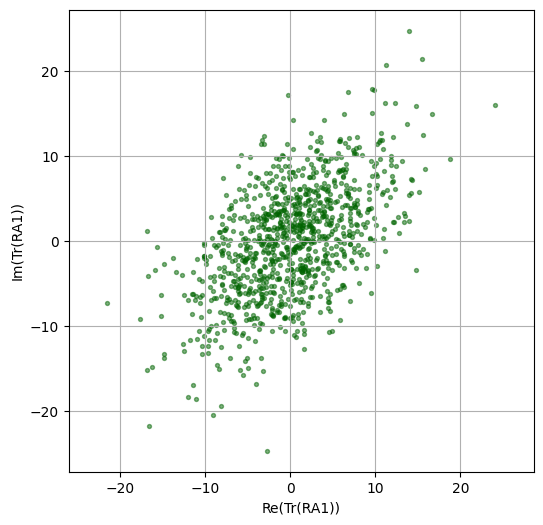

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(re_part, im_part, s=8, alpha=0.5, color='darkgreen')

plt.xlabel('Re(Tr(RA1))')
plt.ylabel('Im(Tr(RA1))')
plt.axis('equal')
plt.grid()

plt.show()

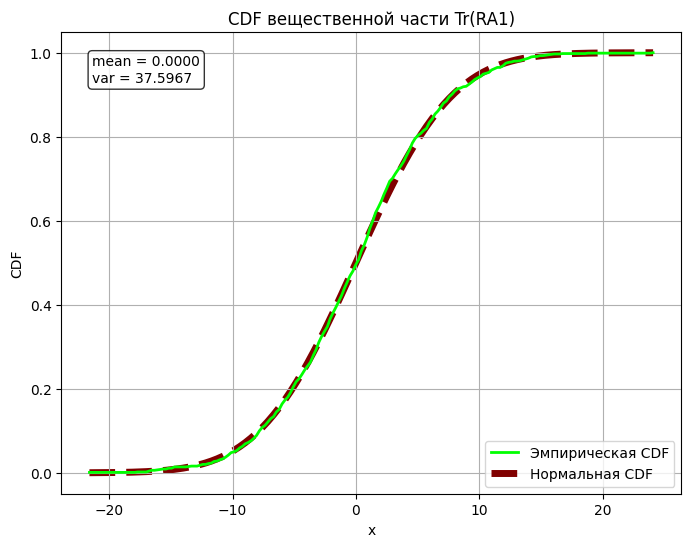

Среднее = 0.00000, Ст. откл. = 6.13162


In [18]:
compare_cdf_with_normal(re_part, title="CDF вещественной части Tr(RA1)")

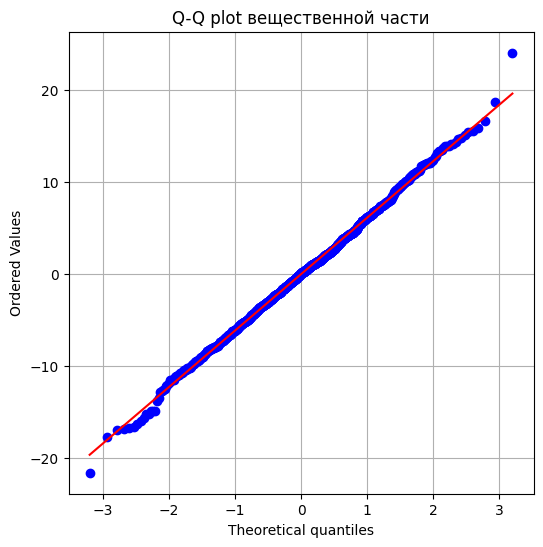

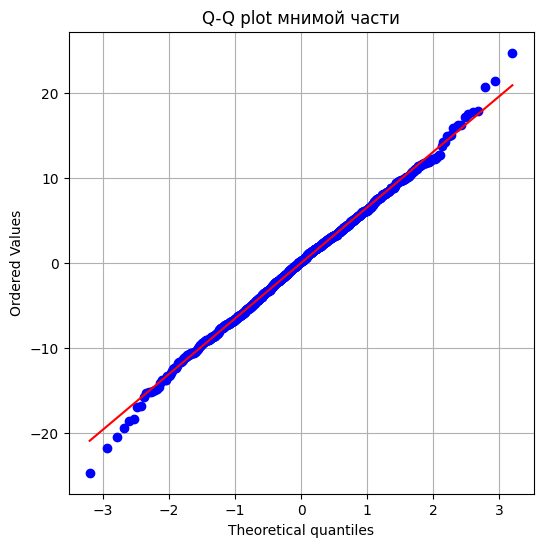

In [19]:
from scipy.stats import probplot

def qq_plot(data, title):
    plt.figure(figsize=(6, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.grid(True)
    plt.show()


qq_plot(re_part, "Q-Q plot вещественной части")
qq_plot(im_part, "Q-Q plot мнимой части")

In [20]:
from scipy.stats import shapiro, normaltest

In [21]:
def test_normality(samples, name="Выборка"):
    """
    Тест Шапиро-Уилка и тест Д'Агостино (нормальности).
    """
    shapiro_stat, shapiro_p = shapiro(samples)
    dagostino_stat, dagostino_p = normaltest(samples)
    
    print(f"\n{name}:")
    print(f"  Шапиро-Уилк: p-value = {shapiro_p:.5f}")
    print(f"  Д'Агостино:  p-value = {dagostino_p:.5f}")
    
    if shapiro_p > 0.05 and dagostino_p > 0.05:
        print("  -> Нет оснований отвергнуть нормальность (p > 0.05)")
    else:
        print("  -> Отклоняем нормальность (p <= 0.05)")

In [22]:
test_normality(re_part, "Вещественная часть")
test_normality(im_part, "Мнимая часть")


Вещественная часть:
  Шапиро-Уилк: p-value = 0.60536
  Д'Агостино:  p-value = 0.33060
  -> Нет оснований отвергнуть нормальность (p > 0.05)

Мнимая часть:
  Шапиро-Уилк: p-value = 0.30437
  Д'Агостино:  p-value = 0.12404
  -> Нет оснований отвергнуть нормальность (p > 0.05)


In [23]:
def test_eta(p, n, z_real, eta_list, num_samples=100, k=1, A_list=None):
    """
    Проверяет нормальность вещественной части.
    Возвращает список p-values (тест Шапиро–Уилка) для каждого eta.
    """
    if A_list is None:
        N_total = p + n
        A_list = [np.eye(N_total)]
    
    pvalues = []
    
    for eta in eta_list:
        z = z_real + 1j * eta
        raw_values = []
        
        for _ in range(num_samples):
            S = generate_S(p, n) 
            val = trace_product(S, z, A_list)
            raw_values.append(val)
        
        raw_values = np.array(raw_values)
        centered = raw_values - np.mean(raw_values)
        re_part = np.real(centered)
        
        # Тест Шапиро-Уилка
        _, pval = shapiro(re_part)
        pvalues.append(pval)
    
    return pvalues

In [24]:
# Список размеров (p, n) с p/n = 0.5
sizes = [
    (50, 100),
    (100, 200),
    (200, 400)
]

z_real_bulk = 1.0

# Список мнимых частей
eta_list_bulk = [0.005, 0.001, 0.0009, 0.0008, 0.0007, 0.0006, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001]

num_samples = 500
threshold = 0.05

In [25]:
for p, n in sizes:
    N_total = p + n
    pvalues = test_eta(p, n, z_real_bulk, eta_list_bulk, num_samples)
    print(f"p={p}, n={n}, N={N_total}")
    for eta, pv in zip(eta_list_bulk, pvalues):
        print(f"  eta={eta:.4f}: p-value={pv:.5f}")
    print()

p=50, n=100, N=150
  eta=0.0050: p-value=0.09160
  eta=0.0010: p-value=0.00009
  eta=0.0009: p-value=0.00017
  eta=0.0008: p-value=0.00000
  eta=0.0007: p-value=0.00000
  eta=0.0006: p-value=0.00000
  eta=0.0005: p-value=0.00000
  eta=0.0004: p-value=0.00000
  eta=0.0003: p-value=0.00000
  eta=0.0002: p-value=0.00000
  eta=0.0001: p-value=0.00000

p=100, n=200, N=300
  eta=0.0050: p-value=0.64040
  eta=0.0010: p-value=0.05833
  eta=0.0009: p-value=0.04514
  eta=0.0008: p-value=0.11546
  eta=0.0007: p-value=0.21881
  eta=0.0006: p-value=0.00314
  eta=0.0005: p-value=0.01129
  eta=0.0004: p-value=0.00003
  eta=0.0003: p-value=0.00000
  eta=0.0002: p-value=0.00000
  eta=0.0001: p-value=0.00000

p=200, n=400, N=600
  eta=0.0050: p-value=0.28866
  eta=0.0010: p-value=0.86202
  eta=0.0009: p-value=0.41704
  eta=0.0008: p-value=0.01307
  eta=0.0007: p-value=0.01585
  eta=0.0006: p-value=0.06219
  eta=0.0005: p-value=0.12227
  eta=0.0004: p-value=0.11387
  eta=0.0003: p-value=0.01148
  eta=0.0

In [26]:
z_real_edge = 1.6571  # правый край минус eps=0.05
#z_real_edge = 0.3429

sizes = [
    (50, 100),
    (100, 200),
    (200, 400)
]

eta_list = [0.5, 0.01, 0.005, 0.0045, 0.004, 0.003, 0.0025, 0.002, 0.001, 0.0009, 0.0008]
num_samples = 500

In [27]:
for p, n in sizes:
    N_total = p + n
    pvalues = test_eta(p, n, z_real_edge, eta_list, num_samples)
    print(f"p={p}, n={n}, N={N_total}")
    for eta, pv in zip(eta_list, pvalues):
        print(f"  eta={eta:.4f}: p-value={pv:.5f}")
    print()

p=50, n=100, N=150
  eta=0.5000: p-value=0.67947
  eta=0.0100: p-value=0.00011
  eta=0.0050: p-value=0.00256
  eta=0.0045: p-value=0.03113
  eta=0.0040: p-value=0.00110
  eta=0.0030: p-value=0.00002
  eta=0.0025: p-value=0.00000
  eta=0.0020: p-value=0.00000
  eta=0.0010: p-value=0.00000
  eta=0.0009: p-value=0.00000
  eta=0.0008: p-value=0.00000

p=100, n=200, N=300
  eta=0.5000: p-value=0.02150
  eta=0.0100: p-value=0.11018
  eta=0.0050: p-value=0.01517
  eta=0.0045: p-value=0.05068
  eta=0.0040: p-value=0.40461
  eta=0.0030: p-value=0.10591
  eta=0.0025: p-value=0.01195
  eta=0.0020: p-value=0.00710
  eta=0.0010: p-value=0.00000
  eta=0.0009: p-value=0.00000
  eta=0.0008: p-value=0.00000

p=200, n=400, N=600
  eta=0.5000: p-value=0.81866
  eta=0.0100: p-value=0.78134
  eta=0.0050: p-value=0.54483
  eta=0.0045: p-value=0.03746
  eta=0.0040: p-value=0.40249
  eta=0.0030: p-value=0.23604
  eta=0.0025: p-value=0.07686
  eta=0.0020: p-value=0.04648
  eta=0.0010: p-value=0.00291
  eta=0.0